# EXAMPLE: FROZENLAKE

ref: https://gymnasium.farama.org/tutorials/training_agents/frozenlake_q_learning/#sphx-glr-tutorials-training-agents-frozenlake-q-learning-py

## Set up env

In [1]:
# Required libs
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map


sns.set_theme()

/app/venvs/An/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import gaussian_kde


In [2]:
# Parameter for the training
class Params(NamedTuple):
    total_episodes: int  # Total episodes
    learning_rate: float  # Learning rate
    gamma: float  # Discounting rate
    max_epsilon: float  # Exploration probability (max)
    min_epsilon: float # Exploration probability (min)
    decay_rate: float # Exponential decay rate for exploration prob
    map_size: int  # Number of tiles of one side of the squared environment
    seed: int  # Define a seed so that we get reproducible results
    is_slippery: bool  # If true the player will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions
    n_runs: int  # Number of runs
    action_size: int  # Number of possible actions
    state_size: int  # Number of possible states
    proba_frozen: float  # Probability that a tile is frozen


In [3]:
params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    max_epsilon=1,
    min_epsilon=0.05,
    decay_rate=0.0005,
    map_size=5,
    seed=123,
    is_slippery=False,
    n_runs=30,
    action_size=None,
    state_size=None,
    proba_frozen=0.9,
)
params

Params(total_episodes=2000, learning_rate=0.8, gamma=0.95, max_epsilon=1, min_epsilon=0.05, decay_rate=0.0005, map_size=5, seed=123, is_slippery=False, n_runs=30, action_size=None, state_size=None, proba_frozen=0.9)

In [4]:
# Set the seed
rng = np.random.default_rng(params.seed)
rng

Generator(PCG64) at 0x7B90BC78A0A0

In [5]:
# # Create env
# env = gym.make(
#     "FrozenLake-v1",
#     is_slippery=params.is_slippery,
#     render_mode="rgb_array",
#     desc=generate_random_map(
#         size=params.map_size, p=params.proba_frozen, seed=params.seed
#     ),
# )

# params = params._replace(action_size=env.action_space.n)
# params = params._replace(state_size=env.observation_space.n)
# print("Action Space Shape", params.action_size)
# print("Sample Action Space", env.action_space.sample())
# print("Observation Space Shape", params.state_size)
# print("Sample Observation", env.observation_space.sample())

## QLearning, Qtable and training

In [6]:
class QLearning:
    ''' 
        Learning from the env and update qtable.
    '''
    def __init__(self, learning_rate: float, gamma: float, state_size: int, action_size: int):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.reset_qtable()

    def update(self, state, action, reward, new_state):
        """Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]"""

        delta = reward + self.gamma * np.max(self.qtable[new_state,:]) - self.qtable[state, action]
        q_update = self.qtable[state, action] + self.learning_rate * delta

        return q_update

    def reset_qtable(self):
        self.qtable = np.zeros((self.state_size, self.action_size))

In [7]:
class EpsilonGreedy:
    '''
        The lower the epsilon, the greedier (more likely it prioritise the exploitation)
    '''
    def __init__(self, epsilon):
        self.epsilon = epsilon # threshold, decide whether the agent is exploring or exploiting

    def update_epsilon(self, new_epsilon):
        self.epsilon = new_epsilon

    def greedy_policy(self, qtable, state) -> np.intp:
        # Exploitation: take the action with the highest state, action value
        max_ids = np.where(qtable[state, :] == max(qtable[state, :]))[0]
        action = rng.choice(max_ids)

        return action

    def choose_action(self, action_space, state, qtable) -> np.intp:
        explor_exploit_tradeoff = rng.uniform(0,1)

        # Exploration 
        if explor_exploit_tradeoff <= self.epsilon:
            return action_space.sample()

        else:
            return self.greedy_policy(qtable, state)

In [8]:
# learner = QLearning(learning_rate=params.learning_rate, 
#                     gamma=params.gamma, 
#                     state_size=params.state_size,
#                     action_size=params.action_size)

# explorer = EpsilonGreedy(epsilon=params.max_epsilon)

In [9]:
def train(episodes: int, run: int, min_epsilon: float, max_epsilon: float, decay_rate: float, env: gym.Env, learner: QLearning, explorer: EpsilonGreedy, rewards: np.array, steps: np.array, all_states: list, all_actions: list):
    '''
        Train env based on qtable.
    '''
    for ep in tqdm(episodes, desc=f"Run {run}/{params.n_runs} - Episodes", leave=False):
        # Reduce epsilon to get less of the exploration and more of the exploitation
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * ep)
        explorer.update_epsilon(new_epsilon=epsilon)
        # if explorer.epsilon >= (min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * 0)):
        #     print(f'Im back again explorer.epsilon = {explorer.epsilon}')
        
        state, info = env.reset(seed=params.seed)
        step = 0
        done = False
        total_rewards = 0

        terminated = False
        truncated = False

        while not done:
            # Choose action based on current state and qtable
            action = explorer.choose_action(action_space=env.action_space, state=state, qtable=learner.qtable)

            # Log state and corresponding action
            all_states.append(state)
            all_actions.append(action)

            # Take action  
            new_state, reward, terminated, truncated, info = env.step(action)

            # Out loop when env state is terminated or truncated
            done = terminated or truncated

            # Update the qtable
            learner.update(state=state, action=action, reward=reward, new_state=new_state)

            total_rewards += reward
            step += 1

            # Update current state 
            state = new_state

        # Log all rewards + steps
        rewards[ep, run] = total_rewards
        steps[ep, run] = step
    
    return rewards, steps, all_states, all_actions

def run_env(env: gym.Env, learner: QLearning, explorer: EpsilonGreedy):
    ''' 
        Run training for n_runs.
    '''
    # Mutiple run
    rewards = np.zeros((params.total_episodes, params.n_runs))
    steps = np.zeros((params.total_episodes, params.n_runs))
    episodes = np.arange(params.total_episodes)
    qtables = np.zeros((params.n_runs, params.state_size, params.action_size))

    all_states = []
    all_actions = []

    for run in range(params.n_runs):
        learner.reset_qtable()

        rewards, steps, all_states, all_actions = train(episodes=episodes, run=run, min_epsilon=params.min_epsilon, max_epsilon=params.max_epsilon, decay_rate=params.decay_rate, env=env, learner=learner, explorer=explorer, rewards=rewards, steps=steps, all_states=all_states, all_actions=all_actions)

        qtables[run, :, :] = learner.qtable

    return rewards, steps, episodes, qtables, all_states, all_actions

## Visualisation

In [10]:
def results_to_df(episodes: int, params: Params, rewards: np.array, steps: np.array, map_size: int):
    ''' 
        Convert results of simulation to df.
    '''
    result = pd.DataFrame(
        data={
            "Episodes": np.tile(episodes, reps=params.n_runs),
            "Rewards": rewards.flatten(order="F"),
            "Steps":steps.flatten(order="F")
        }
    )

    result["cum_rewards"] = rewards.cumsum(axis=0).flatten(order="F")
    result["map_size"] = np.repeat(f"{map_size}x{map_size}", result.shape[0])

    ep_step = pd.DataFrame(
        data= {
            "Episodes": episodes,
            "Steps": steps.mean(axis=1)
        }
    )
    ep_step["map_size"] = np.repeat(f"{map_size}x{map_size}", ep_step.shape[0])

    return result, ep_step

In [11]:
def qtable_directions_map(qtable, map_size):
    """Get the best learned action & map it to arrows."""
    qtable_val_max = qtable.max(axis=1).reshape(map_size, map_size)
    qtable_best_action = np.argmax(qtable, axis=1).reshape(map_size, map_size)
    directions = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    qtable_directions = np.empty(qtable_best_action.flatten().shape, dtype=str)
    eps = np.finfo(float).eps  # Minimum float number on the machine
    
    for idx, val in enumerate(qtable_best_action.flatten()):
        if qtable_val_max.flatten()[idx] > eps:
            # Assign an arrow only if a minimal Q-value has been learned as best action
            # otherwise since 0 is a direction, it also gets mapped on the tiles where
            # it didn't actually learn anything
            qtable_directions[idx] = directions[val]
    qtable_directions = qtable_directions.reshape(map_size, map_size)
    return qtable_val_max, qtable_directions

In [12]:
def plot_q_values_map(qtable, env, map_size):
    """Plot the last frame of the simulation and the policy learned."""
    qtable_val_max, qtable_directions = qtable_directions_map(qtable, map_size)

    # Plot the last frame
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ax[0].imshow(env.render())
    ax[0].axis("off")
    ax[0].set_title("Last frame")

    # Plot the policy
    sns.heatmap(
        qtable_val_max,
        annot=qtable_directions,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title="Learned Q-values\nArrows represent best action")
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")
    plt.show()

In [13]:
def plot_states_actions_distribution(states, actions, map_size):
    """Plot the distributions of states and actions."""
    labels = {"LEFT": 0, "DOWN": 1, "RIGHT": 2, "UP": 3}

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    sns.histplot(data=states, ax=ax[0], kde=True)
    ax[0].set_title("States")
    sns.histplot(data=actions, ax=ax[1])
    ax[1].set_xticks(list(labels.values()), labels=labels.keys())
    ax[1].set_title("Actions")
    fig.tight_layout()
    plt.show()

## RUN

Map size: 4x4


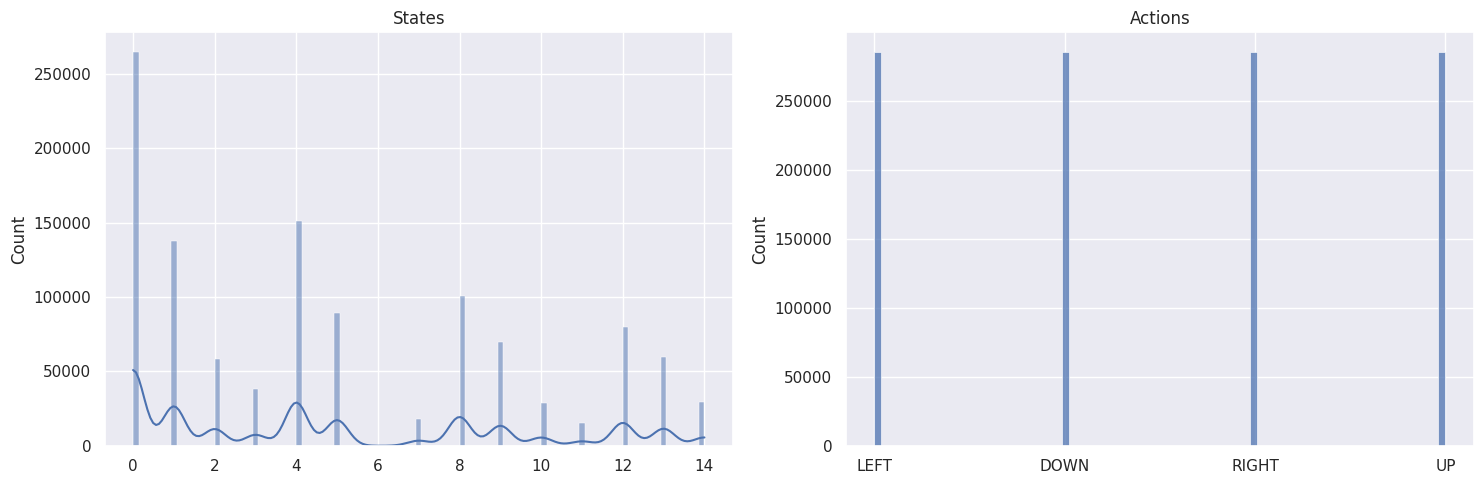

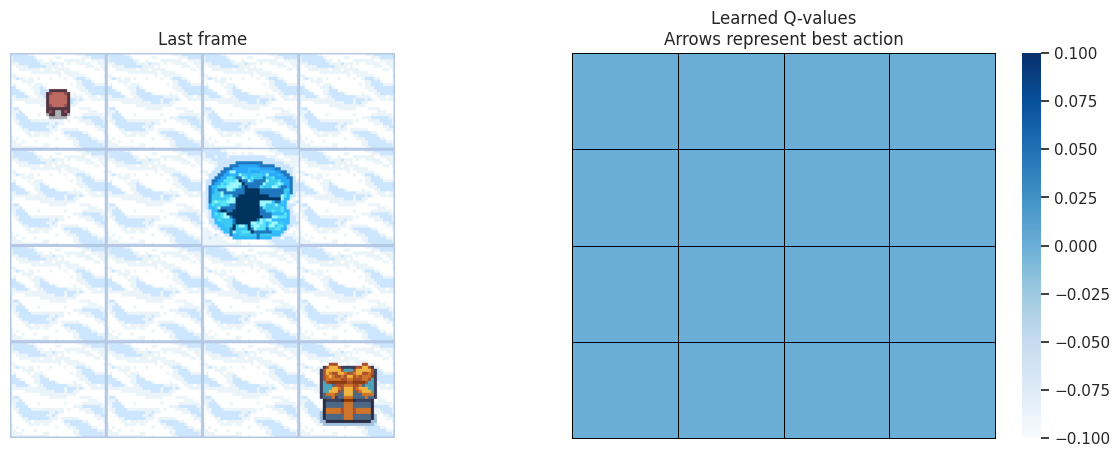

In [14]:
map_sizes = [4]
res_all = pd.DataFrame()
st_all = pd.DataFrame()

for map_size in map_sizes:
    env = gym.make(
        "FrozenLake-v1",
        is_slippery=params.is_slippery,
        render_mode="rgb_array",
        desc=generate_random_map(
            size=map_size, p=params.proba_frozen, seed=params.seed
        ),
    )

    params = params._replace(action_size=env.action_space.n)
    params = params._replace(state_size=env.observation_space.n)
    env.action_space.seed(
        params.seed
    )  # Set the seed to get reproducible results when sampling the action space
    
    learner = QLearning(
        learning_rate=params.learning_rate,
        gamma=params.gamma,
        state_size=params.state_size,
        action_size=params.action_size,
    )
    explorer = EpsilonGreedy(
        epsilon=params.max_epsilon,
    )

    print(f"Map size: {map_size}x{map_size}")
    rewards, steps, episodes, qtables, all_states, all_actions = run_env(env=env, learner=learner, explorer=explorer)

    # Save the results in dataframes
    res, st = results_to_df(episodes, params, rewards, steps, map_size)
    res_all = pd.concat([res_all, res])
    st_all = pd.concat([st_all, st])
    qtable = qtables.mean(axis=0)  # Average the Q-table between runs

    plot_states_actions_distribution(
        states=all_states, actions=all_actions, map_size=map_size
    )  # Sanity check
    plot_q_values_map(qtable, env, map_size)

    env.close()

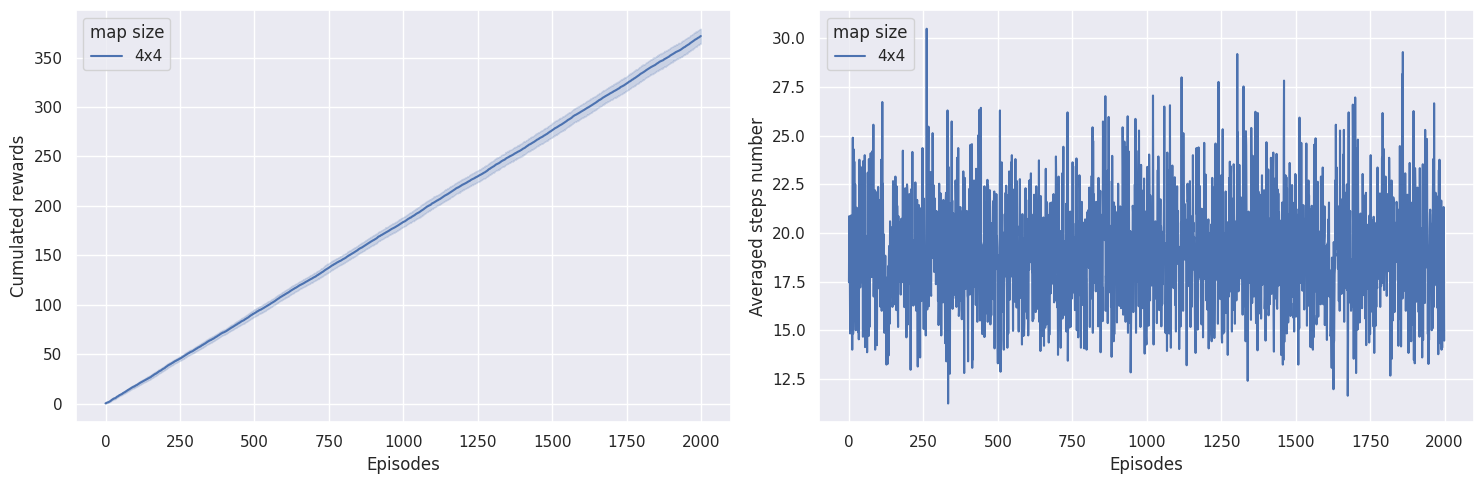

In [15]:
def plot_steps_and_rewards(rewards_df, steps_df):
    """Plot the steps and rewards from dataframes."""
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    sns.lineplot(
        data=rewards_df, x="Episodes", y="cum_rewards", hue="map_size", ax=ax[0]
    )
    ax[0].set(ylabel="Cumulated rewards")

    sns.lineplot(data=steps_df, x="Episodes", y="Steps", hue="map_size", ax=ax[1])
    ax[1].set(ylabel="Averaged steps number")

    for axi in ax:
        axi.legend(title="map size")
    fig.tight_layout()
    plt.show()


plot_steps_and_rewards(res_all, st_all)